# Adversarial Robustness of Medical Image Segmentation Models

**Project overview**

1. Train a 3D UNet (MONAI) for hippocampus segmentation on the Medical Segmentation Decathlon (Task04).
2. Attack the trained model with **FGSM** (Fast Gradient Sign Method) and measure how segmentation quality
   (Dice score) degrades as the perturbation strength (epsilon) increases.
3. Make the model more robust via **adversarial training** (training on a mix of clean and FGSM-perturbed
   images), and compare it against the standard model.
4. Validate the robustness claim with **PGD** (Projected Gradient Descent), a much stronger iterative attack —
   this step is essential because FGSM-trained models can sometimes look robust only because they "mask"
   their gradients, not because they are actually more robust (see the discussion in Part 4).

**Why this project matters:** medical AI models are increasingly deployed in clinical pipelines, but very few
of them are ever tested against adversarial perturbations before deployment. This notebook is a small,
self-contained demonstration of what that kind of robustness evaluation looks like, sitting at the
intersection of AI, security, and biomedical engineering.


## Part 0 - Setup

In [ ]:
!pip install -q "monai-weekly[nibabel, tqdm]" torch torchvision
import monai
print("MONAI version:", monai.__version__)
import torch
print("Torch version:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.1 MB/s eta 0:00:00
MONAI version: 1.7.dev2627
Torch version: 2.11.0+cu128 | CUDA available: True


In [ ]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

from monai.apps import DecathlonDataset
from monai.data import DataLoader
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    ScaleIntensityd,
    Resized,
    Lambdad,
    EnsureTyped,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

root_dir = "./data"
os.makedirs(root_dir, exist_ok=True)


Using device: cuda


## Part 1 - Data & Baseline Model

We use **Task04_Hippocampus** from the Medical Segmentation Decathlon: small 3D MRI volumes, which makes
this the fastest Decathlon dataset to download and train on. We simplify the original 3-class label
(background / anterior / posterior) into a binary mask (background vs. hippocampus) to keep the pipeline
simple and easy to reason about.

In [ ]:
def binarize_label(x):
    """Collapse the 2 foreground classes (anterior/posterior hippocampus) into a single foreground class."""
    return (x > 0).astype(np.float32)

spatial_size = (64, 64, 32)  # fixed small size -> whole-volume training, no patch sampling needed

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityd(keys="image"),                 # scales image intensities to [0, 1]
    Lambdad(keys="label", func=binarize_label),
    Resized(keys=["image", "label"], spatial_size=spatial_size, mode=("trilinear", "nearest")),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = train_transforms  # same pipeline, kept separate in case you want to diverge later

train_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task04_Hippocampus",
    transform=train_transforms,
    section="training",
    download=True,
    cache_rate=1.0,
    num_workers=2,
)

val_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task04_Hippocampus",
    transform=val_transforms,
    section="validation",
    download=False,
    cache_rate=1.0,
    num_workers=2,
)

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
Task04_Hippocampus.tar: 27.1MB [00:00, 37.6MB/s]                            

2026-07-05 16:57:43,291 - INFO - Downloaded: data/Task04_Hippocampus.tar
2026-07-05 16:57:43,350 - INFO - Verified 'Task04_Hippocampus.tar', md5: 9d24dba78a72977dbd1d2e110310f31b.
2026-07-05 16:57:43,353 - INFO - Writing into directory: data.



Loading dataset: 100%|██████████| 52/52 [00:01<00:00, 38.46it/s]

Training samples: 208
Validation samples: 52


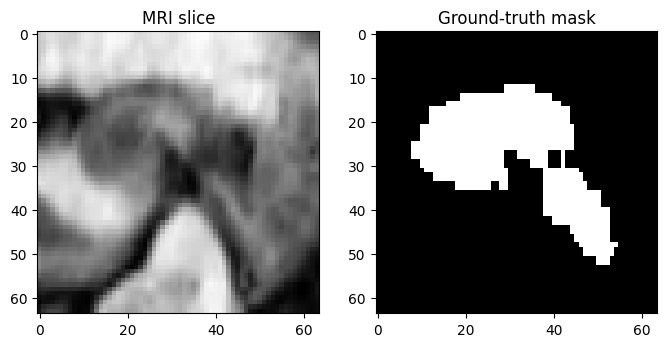

In [ ]:
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2)

# Quick sanity check: visualize one training sample
sample = train_ds[0]
image, label = sample["image"], sample["label"]
mid_slice = image.shape[-1] // 2

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image[0, :, :, mid_slice], cmap="gray")
axes[0].set_title("MRI slice")
axes[1].imshow(label[0, :, :, mid_slice], cmap="gray")
axes[1].set_title("Ground-truth mask")
plt.show()


In [ ]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2,
).to(device)

loss_function = DiceLoss(sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
dice_metric = DiceMetric(include_background=True, reduction="mean")

print(model)


UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

Epoch 1/30 - loss: 0.8304
Epoch 5/30 - loss: 0.6555
Epoch 10/30 - loss: 0.2886
Epoch 15/30 - loss: 0.1470
Epoch 20/30 - loss: 0.1012
Epoch 25/30 - loss: 0.0846
Epoch 30/30 - loss: 0.0720


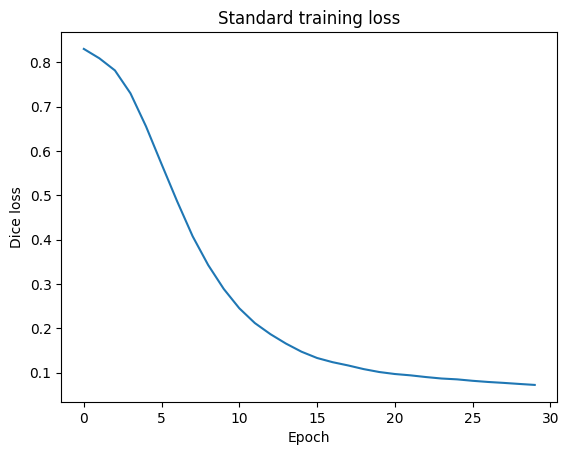

In [ ]:
max_epochs = 30
train_losses = []

for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_data in train_loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{max_epochs} - loss: {epoch_loss:.4f}")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Dice loss")
plt.title("Standard training loss")
plt.show()


In [ ]:
def evaluate(model, loader):
    """Clean-data Dice score, no attack."""
    model.eval()
    dice_metric.reset()
    with torch.no_grad():
        for batch_data in loader:
            inputs = batch_data["image"].to(device)
            labels = batch_data["label"].to(device)
            outputs = torch.sigmoid(model(inputs))
            outputs = (outputs > 0.5).float()
            dice_metric(y_pred=outputs, y=labels)
        mean_dice = dice_metric.aggregate().item()
    return mean_dice

baseline_dice = evaluate(model, val_loader)
print(f"Clean validation Dice: {baseline_dice:.4f}")


Clean validation Dice: 0.8690


## Part 2 - FGSM Attack

FGSM perturbs the input in the direction that **most increases the loss**, using only the sign of the
gradient. It is a single-step, "cheap" attack, fast to compute, but also relatively easy for a model to
become robust against (which is exactly why we validate with PGD in Part 4).

In [ ]:
def fgsm_attack(model, loss_fn, images, labels, epsilon):
    """
    Single-step adversarial perturbation.
    images are perturbed in the direction that increases the loss the most, scaled by epsilon.
    """
    images = images.clone().detach().to(device)
    images.requires_grad = True

    outputs = model(images)
    loss = loss_fn(outputs, labels)

    model.zero_grad()
    loss.backward()

    data_grad = images.grad.data
    perturbed_images = images + epsilon * data_grad.sign()
    # Images live in [0, 1] because of ScaleIntensityd, so we clip back into that range.
    perturbed_images = torch.clamp(perturbed_images, 0, 1)
    return perturbed_images.detach()


def evaluate_under_fgsm(model, loader, epsilon):
    """Dice score after applying an FGSM attack with the given epsilon to every validation batch."""
    model.eval()
    dice_metric.reset()
    for batch_data in loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        if epsilon > 0:
            inputs = fgsm_attack(model, loss_function, inputs, labels, epsilon)

        with torch.no_grad():
            outputs = torch.sigmoid(model(inputs))
            outputs = (outputs > 0.5).float()
            dice_metric(y_pred=outputs, y=labels)

    return dice_metric.aggregate().item()


In [ ]:
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1, 0.2]
fgsm_results = []

for eps in epsilons:
    dice = evaluate_under_fgsm(model, val_loader, eps)
    fgsm_results.append({"epsilon": eps, "mean_dice": dice, "model": "standard", "attack": "FGSM"})
    print(f"epsilon = {eps:.2f}  ->  mean Dice = {dice:.4f}")

fgsm_results_df = pd.DataFrame(fgsm_results)
fgsm_results_df


epsilon = 0.00  ->  mean Dice = 0.8690
epsilon = 0.01  ->  mean Dice = 0.7435
epsilon = 0.03  ->  mean Dice = 0.6419
epsilon = 0.05  ->  mean Dice = 0.5878
epsilon = 0.10  ->  mean Dice = 0.5060
epsilon = 0.20  ->  mean Dice = 0.4271


,epsilon,mean_dice,model,attack
0,0.00,0.869000,standard,FGSM
1,0.01,0.743456,standard,FGSM
2,0.03,0.641944,standard,FGSM
3,0.05,0.587833,standard,FGSM
4,0.10,0.506037,standard,FGSM
5,0.20,0.427113,standard,FGSM


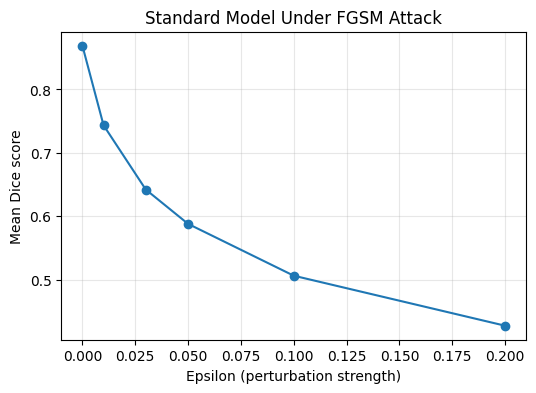

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(fgsm_results_df["epsilon"], fgsm_results_df["mean_dice"], marker="o")
plt.xlabel("Epsilon (perturbation strength)")
plt.ylabel("Mean Dice score")
plt.title("Standard Model Under FGSM Attack")
plt.grid(True, alpha=0.3)
plt.savefig("fgsm_dice_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 3 - Adversarial Training

We now train a **second model from scratch**, using the same architecture, but this time every training
batch is a mix of clean and FGSM-perturbed images. The attack is generated fresh at every step, using the
model's current weights, so the "worst case" the model sees keeps shifting as training progresses.

Expect a trade-off: this model should be somewhat more robust to FGSM, but very likely slightly worse on
clean data than the standard model.

In [ ]:
def adversarial_train_epoch(model, loader, optimizer, loss_fn, epsilon=0.05, adv_ratio=0.5):
    """
    One epoch of adversarial training.

    epsilon:   FGSM perturbation strength used during training.
    adv_ratio: fraction of each batch replaced by its adversarial version (0.5 = half clean, half adversarial).
    """
    model.train()
    epoch_loss = 0.0

    for batch_data in loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        # 1) Generate adversarial examples using the model's CURRENT weights.
        adv_inputs = fgsm_attack(model, loss_fn, inputs, labels, epsilon)

        # 2) Build a mixed batch of clean + adversarial samples.
        batch_size = inputs.size(0)
        n_adv = max(1, int(batch_size * adv_ratio))
        combined_inputs = torch.cat([inputs[n_adv:], adv_inputs[:n_adv]], dim=0)
        combined_labels = torch.cat([labels[n_adv:], labels[:n_adv]], dim=0)

        # 3) Standard training step, but on the mixed batch.
        optimizer.zero_grad()
        outputs = model(combined_inputs)
        loss = loss_fn(outputs, combined_labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


[Adversarial training] epoch 1/30 - loss: 0.8588
[Adversarial training] epoch 5/30 - loss: 0.7240
[Adversarial training] epoch 10/30 - loss: 0.3727
[Adversarial training] epoch 15/30 - loss: 0.2155
[Adversarial training] epoch 20/30 - loss: 0.1775
[Adversarial training] epoch 25/30 - loss: 0.1532
[Adversarial training] epoch 30/30 - loss: 0.1355


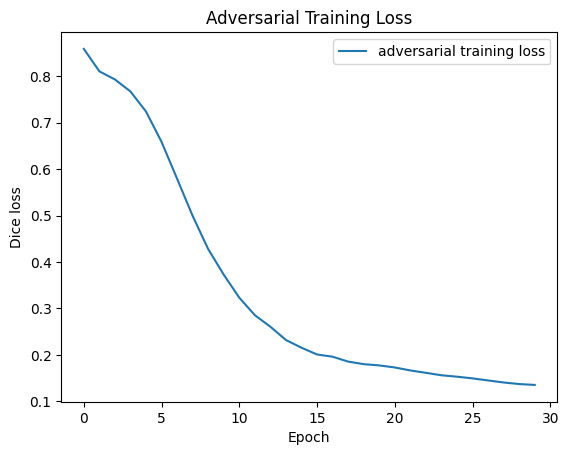

In [ ]:
robust_model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2,
).to(device)

robust_optimizer = torch.optim.Adam(robust_model.parameters(), lr=1e-3)

adv_epochs = 30
adv_train_losses = []
train_epsilon = 0.05  # perturbation strength used DURING training (can differ from evaluation epsilons)

for epoch in range(adv_epochs):
    epoch_loss = adversarial_train_epoch(
        robust_model, train_loader, robust_optimizer, loss_function,
        epsilon=train_epsilon, adv_ratio=0.5,
    )
    adv_train_losses.append(epoch_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"[Adversarial training] epoch {epoch+1}/{adv_epochs} - loss: {epoch_loss:.4f}")

plt.plot(adv_train_losses, label="adversarial training loss")
plt.xlabel("Epoch")
plt.ylabel("Dice loss")
plt.title("Adversarial Training Loss")
plt.legend()
plt.show()


In [ ]:
fgsm_results_df_labeled = fgsm_results_df.copy()

robust_fgsm_results = []
for eps in epsilons:
    dice = evaluate_under_fgsm(robust_model, val_loader, eps)
    robust_fgsm_results.append({"epsilon": eps, "mean_dice": dice, "model": "adversarially_trained", "attack": "FGSM"})
    print(f"[Robust model] epsilon={eps:.2f} -> Dice={dice:.4f}")

robust_fgsm_df = pd.DataFrame(robust_fgsm_results)
fgsm_comparison_df = pd.concat([fgsm_results_df_labeled, robust_fgsm_df], ignore_index=True)
fgsm_comparison_df


[Robust model] epsilon=0.00 -> Dice=0.8452
[Robust model] epsilon=0.01 -> Dice=0.8259
[Robust model] epsilon=0.03 -> Dice=0.7939
[Robust model] epsilon=0.05 -> Dice=0.7695
[Robust model] epsilon=0.10 -> Dice=0.7282
[Robust model] epsilon=0.20 -> Dice=0.6809


,epsilon,mean_dice,model,attack
0,0.00,0.869000,standard,FGSM
1,0.01,0.743456,standard,FGSM
2,0.03,0.641944,standard,FGSM
3,0.05,0.587833,standard,FGSM
4,0.10,0.506037,standard,FGSM
5,0.20,0.427113,standard,FGSM
6,0.00,0.845191,adversarially_trained,FGSM
7,0.01,0.825903,adversarially_trained,FGSM
8,0.03,0.793924,adversarially_trained,FGSM
9,0.05,0.769456,adversarially_trained,FGSM


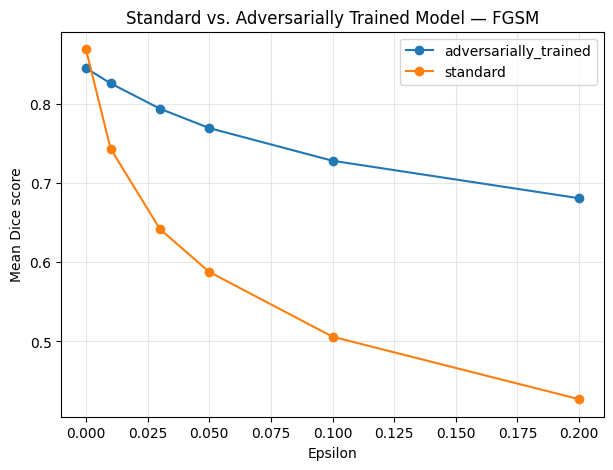

In [ ]:
plt.figure(figsize=(7, 5))
for model_name, group in fgsm_comparison_df.groupby("model"):
    plt.plot(group["epsilon"], group["mean_dice"], marker="o", label=model_name)

plt.xlabel("Epsilon")
plt.ylabel("Mean Dice score")
plt.title("Standard vs. Adversarially Trained Model — FGSM")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("fgsm_standard_vs_robust.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 4 - Validating Robustness With PGD

**Why this step matters:** a model trained against FGSM can sometimes look robust for the wrong reason -
by learning a loss surface with unhelpful or misleading gradients ("gradient masking"), rather than by
actually learning a more robust decision boundary. The standard way to check for this is to attack the
model with **PGD (Projected Gradient Descent)**: unlike FGSM's single step, PGD takes several small steps,
each one following the local gradient, and after each step it "projects" the perturbation back into an
epsilon-ball around the original image. This produces a much stronger, more realistic worst-case attack.

If the adversarially-trained model holds up reasonably well under PGD (not just FGSM), that is real evidence
of robustness. If its Dice score collapses under PGD despite looking robust under FGSM, that is a strong
sign of gradient masking rather than genuine robustness.

In [ ]:
def pgd_attack(model, loss_fn, images, labels, epsilon, alpha, num_iter):
    """
    Multi-step adversarial attack.

    epsilon:  maximum allowed perturbation size (L-infinity ball radius)
    alpha:    step size for each iteration (typically epsilon / 4 to epsilon / 10)
    num_iter: number of gradient steps
    """
    original_images = images.clone().detach().to(device)
    perturbed = original_images.clone().detach()

    for _ in range(num_iter):
        perturbed.requires_grad = True
        outputs = model(perturbed)
        loss = loss_fn(outputs, labels)

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            grad_sign = perturbed.grad.sign()
            perturbed = perturbed + alpha * grad_sign
            # Project the perturbation back into the epsilon-ball around the original image.
            eta = torch.clamp(perturbed - original_images, min=-epsilon, max=epsilon)
            perturbed = torch.clamp(original_images + eta, 0, 1)

        perturbed = perturbed.detach()

    return perturbed


def evaluate_under_pgd(model, loader, epsilon, num_iter=10):
    """Dice score after applying a PGD attack with the given epsilon to every validation batch."""
    model.eval()
    dice_metric.reset()
    alpha = epsilon / 4 if epsilon > 0 else 0.0

    for batch_data in loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        if epsilon > 0:
            inputs = pgd_attack(model, loss_function, inputs, labels, epsilon, alpha, num_iter)

        with torch.no_grad():
            outputs = torch.sigmoid(model(inputs))
            outputs = (outputs > 0.5).float()
            dice_metric(y_pred=outputs, y=labels)

    return dice_metric.aggregate().item()


In [ ]:
pgd_results = []

for eps in epsilons:
    dice_standard = evaluate_under_pgd(model, val_loader, eps, num_iter=10)
    dice_robust = evaluate_under_pgd(robust_model, val_loader, eps, num_iter=10)

    pgd_results.append({"epsilon": eps, "mean_dice": dice_standard, "model": "standard", "attack": "PGD"})
    pgd_results.append({"epsilon": eps, "mean_dice": dice_robust, "model": "adversarially_trained", "attack": "PGD"})

    print(f"epsilon={eps:.2f}  standard={dice_standard:.4f}  adversarially_trained={dice_robust:.4f}")

pgd_results_df = pd.DataFrame(pgd_results)
pgd_results_df


epsilon=0.00  standard=0.8690  adversarially_trained=0.8452
epsilon=0.01  standard=0.4063  adversarially_trained=0.8227
epsilon=0.03  standard=0.0131  adversarially_trained=0.7624
epsilon=0.05  standard=0.0004  adversarially_trained=0.6633
epsilon=0.10  standard=0.0001  adversarially_trained=0.3212
epsilon=0.20  standard=0.0001  adversarially_trained=0.0397


,epsilon,mean_dice,model,attack
0,0.00,0.869000,standard,PGD
1,0.00,0.845191,adversarially_trained,PGD
2,0.01,0.406317,standard,PGD
3,0.01,0.822691,adversarially_trained,PGD
4,0.03,0.013139,standard,PGD
5,0.03,0.762385,adversarially_trained,PGD
6,0.05,0.000363,standard,PGD
7,0.05,0.663257,adversarially_trained,PGD
8,0.10,0.000111,standard,PGD
9,0.10,0.321158,adversarially_trained,PGD


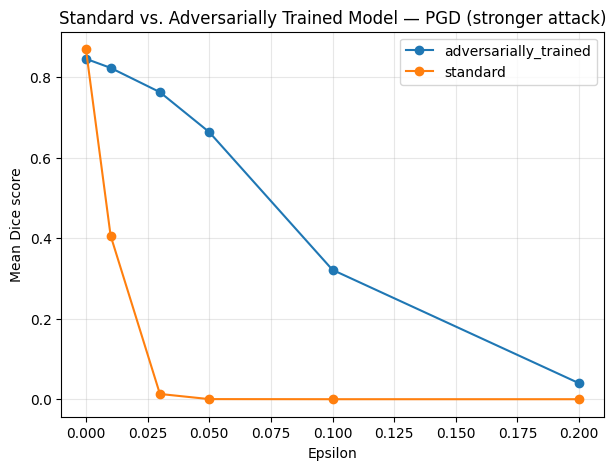

In [ ]:
plt.figure(figsize=(7, 5))
for model_name, group in pgd_results_df.groupby("model"):
    plt.plot(group["epsilon"], group["mean_dice"], marker="o", label=model_name)

plt.xlabel("Epsilon")
plt.ylabel("Mean Dice score")
plt.title("Standard vs. Adversarially Trained Model — PGD (stronger attack)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("pgd_standard_vs_robust.png", dpi=150, bbox_inches="tight")
plt.show()


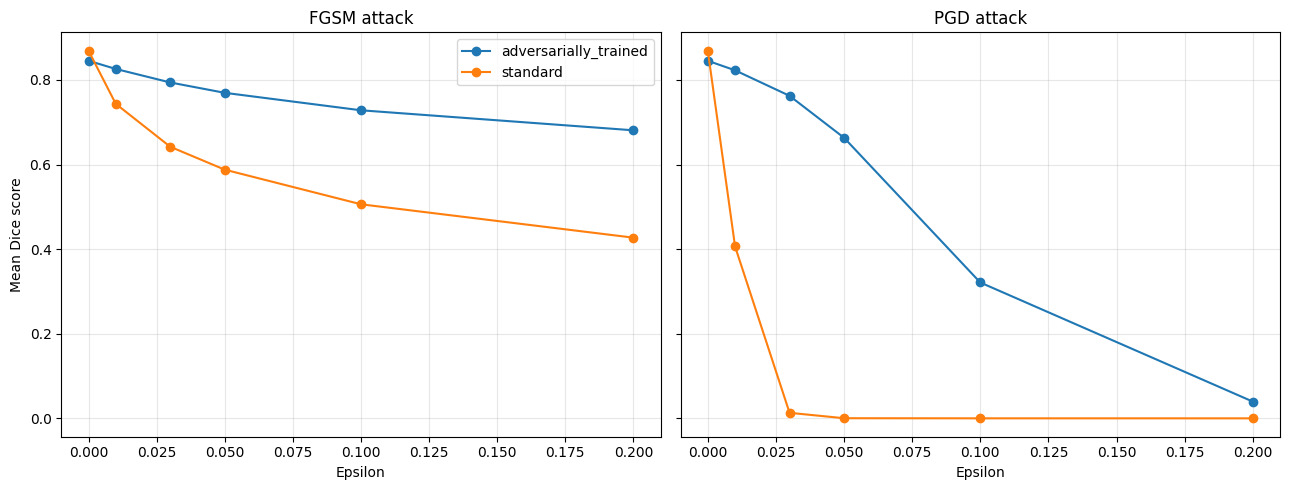

In [ ]:
# Side-by-side view: does the robust model's advantage survive under the stronger PGD attack,
# or does it shrink compared to what we saw under FGSM? This is the key diagnostic for gradient masking.
full_comparison_df = pd.concat([fgsm_comparison_df, pgd_results_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, attack_name in zip(axes, ["FGSM", "PGD"]):
    subset = full_comparison_df[full_comparison_df["attack"] == attack_name]
    for model_name, group in subset.groupby("model"):
        ax.plot(group["epsilon"], group["mean_dice"], marker="o", label=model_name)
    ax.set_title(f"{attack_name} attack")
    ax.set_xlabel("Epsilon")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Mean Dice score")
axes[0].legend()
plt.tight_layout()
plt.savefig("fgsm_vs_pgd_full_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

full_comparison_df.to_csv("full_robustness_comparison.csv", index=False)


### How to read this result

- If the gap between "standard" and "adversarially_trained" is **similar** under FGSM and PGD, the
  adversarial training genuinely improved robustness.
- If the "adversarially_trained" model looks strong under FGSM but its Dice score **collapses under PGD**
  (dropping close to the standard model's PGD performance, or below it), that is evidence of gradient
  masking — the model learned to defeat the specific one-step FGSM attack rather than becoming genuinely
  more robust.

## Part 5 - Saving Results

In [ ]:
torch.save(model.state_dict(), "hippocampus_unet_standard.pth")
torch.save(robust_model.state_dict(), "hippocampus_unet_robust.pth")
full_comparison_df.to_csv("full_robustness_comparison.csv", index=False)

print("Saved: hippocampus_unet_standard.pth, hippocampus_unet_robust.pth, full_robustness_comparison.csv")
print("Saved figures: fgsm_dice_curve.png, fgsm_standard_vs_robust.png, pgd_standard_vs_robust.png, fgsm_vs_pgd_full_comparison.png")


Saved: hippocampus_unet_standard.pth, hippocampus_unet_robust.pth, full_robustness_comparison.csv
Saved figures: fgsm_dice_curve.png, fgsm_standard_vs_robust.png, pgd_standard_vs_robust.png, fgsm_vs_pgd_full_comparison.png
